In [1]:
!pip install -q langchain-mistralai langgraph python-dotenv

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, RemoveMessage
from langchain_mistralai import ChatMistralAI
from langgraph.graph.message import add_messages

In [3]:
from google.colab import userdata
import os
os.environ["MISTRAL_API_KEY"] = userdata.get('MISTRAL_API_KEY')

In [4]:
# DELIBERATELY hardcoded -- see MISTRAL_MODEL_LIMITS.md: mistral-small-latest
# has zero request allowance on many accounts (hard 429).
llm = ChatMistralAI(model="ministral-8b-latest")

In [5]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [6]:
def chat_node(state: ChatState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

In [7]:
def delete_old_messages(state: ChatState):
    messages = state["messages"]

    # Keep only the last 2 messages -- everything before that gets a
    # RemoveMessage built for it, one per message being deleted.
    if len(messages) <= 2:
        return {}

    messages_to_delete = messages[:-2]

    # RemoveMessage(id=...) is a SPECIAL message type the add_messages
    # reducer specifically recognizes. Instead of appending like a normal
    # message, add_messages sees a RemoveMessage and DELETES the message with
    # that matching id from state["messages"] -- this is the ONLY way to
    # actually shrink state["messages"], as opposed to trim_messages() (last
    # notebook), which only filtered what got SENT to the LLM without ever
    # touching the stored state itself.
    return {
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete]
    }

In [8]:
graph_builder = StateGraph(ChatState)

graph_builder.add_node("chat_node", chat_node)
graph_builder.add_node("delete_old_messages", delete_old_messages)

graph_builder.add_edge(START, "chat_node")
graph_builder.add_edge("chat_node", "delete_old_messages")
graph_builder.add_edge("delete_old_messages", END)

graph = graph_builder.compile()

In [9]:
result = graph.invoke({"messages": [HumanMessage(content="Hi, I'm exploring career options after graduation.")]})

for m in result["messages"]:
    print(m.content)

Hi, I'm exploring career options after graduation.
That’s a great step—exploring career options after graduation can feel overwhelming, but it’s also exciting! Here’s a structured approach to help you navigate this process effectively:

---

### **1. Self-Assessment: Know Yourself**
Before exploring careers, clarify your strengths, interests, values, and goals.
- **Skills & Strengths**:
  - What subjects, projects, or activities did you enjoy most in school/work?
  - Tools/software you’re proficient in (e.g., coding, design, data analysis).
  - Soft skills (e.g., leadership, communication, creativity).
  - *Tools*: Take free assessments like [16Personalities](https://www.16personalities.com/), [O*NET Interest Profiler](https://www.mynextmove.org/explore/ip), or [CliftonStrengths](https://www.gallup.com/cliftonstrengths/en/home.aspx).

- **Interests**:
  - What topics do you love learning about? (e.g., tech, sustainability, healthcare, arts).
  - Hobbies or side projects? (e.g., bloggin

In [10]:
len(result["messages"])

2

In [11]:
result = graph.invoke({"messages": result["messages"] + [HumanMessage(content="I have a background in computer science.")]})

for m in result["messages"]:
    print(m.content)

I have a background in computer science.
With a **Computer Science (CS) background**, you have **one of the most versatile and in-demand skill sets** in today’s job market. Your options span **tech, non-tech, entrepreneurship, and emerging fields** like AI, cybersecurity, and fintech. Below is a **structured breakdown** of career paths, strategies, and actionable steps tailored to your background.

---

## **1. Core CS Career Paths (High Demand, High Pay)**
These roles leverage your technical skills directly and often pay **$80K–$150K+** for entry-level positions.

| **Role**               | **What You’ll Do**                                                                 | **Entry-Level Jobs**                          | **Skills to Highlight**                          | **Salary Range (US)** |
|------------------------|-----------------------------------------------------------------------------------|-----------------------------------------------|-----------------------------------

In [12]:
len(result["messages"])

2

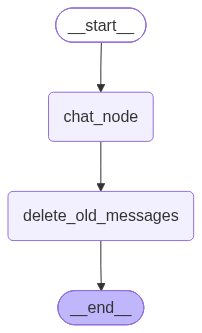

In [13]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	chat_node(chat_node)
	delete_old_messages(delete_old_messages)
	__end__([<p>__end__</p>]):::last
	__start__ --> chat_node;
	chat_node --> delete_old_messages;
	delete_old_messages --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

